# 10 — Inference

Load the trained model and all artifacts, then generate predictions for new/unseen data.


In [1]:
import pandas as pd
import numpy as np
import joblib, yaml, json, warnings
warnings.filterwarnings('ignore')

with open('../configs/paths.yaml') as f:
    paths = yaml.safe_load(f)
with open('../configs/config.yaml') as f:
    cfg = yaml.safe_load(f)

MODEL_PATH  = f'../{paths["artifacts"]["models"]}tuned_model.pkl'
SCALER_PATH = f'../{paths["artifacts"]["models"]}scaler.pkl'
PARAMS_PATH = f'../{paths["artifacts"]["models"]}best_params.json'

model  = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
with open(PARAMS_PATH) as f:
    best_params = json.load(f)

print('Model loaded :', type(model).__name__)
print('Best params  :', best_params)

Model loaded : XGBRegressor
Best params  : {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.6}


In [2]:
# ── Feature engineering helper (mirrors NB-05 logic) ─────────────────────────
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['comfort_index']   = df['temp'] - 0.5 * df['hum'] / 100
    df['is_weekend']      = df['weekday'].isin([0, 6]).astype(int)
    df['quarter']         = pd.cut(df['mnth'], bins=[0,3,6,9,12], labels=[1,2,3,4]).astype(int)
    df['is_warm_season']  = df['season'].isin([2, 3]).astype(int)
    df['is_bad_weather']  = (df['weathersit'] >= 3).astype(int)
    df['temp_yr']         = df['temp'] * df['yr']
    return df

# ── Preprocessing helper ──────────────────────────────────────────────────────
def preprocess(df: pd.DataFrame, scaler, cfg: dict) -> pd.DataFrame:
    DROP = cfg['features']['drop_columns']
    df = df.drop(columns=[c for c in DROP if c in df.columns])
    if 'dteday' in df.columns:
        df = df.drop(columns=['dteday'])
    NUM = cfg['features']['numeric']
    df[NUM] = scaler.transform(df[NUM])
    return df

print('Helpers defined.')

Helpers defined.


In [3]:
# ── Inference function ────────────────────────────────────────────────────────
def predict(input_df: pd.DataFrame) -> np.ndarray:
    """
    Input: raw DataFrame with same columns as the original dataset
            (minus target: cnt, casual, registered).
    Output: numpy array of predicted daily bike counts.
    """
    df_fe = add_engineered_features(input_df)
    df_pr = preprocess(df_fe, scaler, cfg)
    return model.predict(df_pr)

print('predict() ready.')

predict() ready.


In [4]:
# ── Demo 1: Single-row prediction ─────────────────────────────────────────────
single_input = pd.DataFrame([{
    'season': 3,         # Fall
    'yr': 1,             # 2019
    'mnth': 9,           # September
    'holiday': 0,
    'weekday': 3,        # Wednesday
    'workingday': 1,
    'weathersit': 1,     # Clear
    'temp': 25.0,
    'atemp': 26.5,
    'hum': 55.0,
    'windspeed': 12.0,
}])

pred = predict(single_input)
print(f'Predicted daily bike demand: {pred[0]:.0f} rentals')

Predicted daily bike demand: 5397 rentals


In [5]:
# ── Demo 2: Batch prediction on test set ──────────────────────────────────────
df_raw = pd.read_csv(f'../{paths["data"]["raw"]}')
df_raw['dteday'] = pd.to_datetime(df_raw['dteday'], dayfirst=True)

TEST_SIZE  = cfg['project']['test_size']
TARGET     = cfg['project']['target']
split_idx  = int(len(df_raw) * (1 - TEST_SIZE))

df_test_raw = df_raw.iloc[split_idx:].drop(columns=[TARGET, 'casual', 'registered'])
preds_batch = predict(df_test_raw)

result_df = pd.DataFrame({
    'date':     df_raw['dteday'].iloc[split_idx:].values,
    'actual':   df_raw[TARGET].iloc[split_idx:].values,
    'predicted': preds_batch.round(0).astype(int),
})
result_df['error'] = result_df['actual'] - result_df['predicted']
result_df['abs_error'] = result_df['error'].abs()

print(f'Batch predictions for {len(result_df)} test days:')
result_df.head(10)

Batch predictions for 146 test days:


,date,actual,predicted,error,abs_error
0,2019-08-08,7534,5334,2200,2200
1,2019-08-09,7286,5525,1761,1761
2,2019-08-10,5786,5664,122,122
3,2019-08-11,6299,5784,515,515
4,2019-08-12,6544,5350,1194,1194
5,2019-08-13,6883,5289,1594,1594
6,2019-08-14,6784,5552,1232,1232
7,2019-08-15,7347,5587,1760,1760
8,2019-08-16,7605,5541,2064,2064
9,2019-08-17,7148,5843,1305,1305


In [6]:
# ── Summary metrics ───────────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Inference Evaluation')
print(f'  R²  : {r2_score(result_df["actual"], result_df["predicted"]):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(result_df["actual"], result_df["predicted"])):.2f}')
print(f'  MAE : {mean_absolute_error(result_df["actual"], result_df["predicted"]):.2f}')

Inference Evaluation
  R²  : 0.1260
  RMSE: 1755.29
  MAE : 1597.85


In [7]:
# ── Save predictions to output ────────────────────────────────────────────────
out_path = f'../{paths["artifacts"]["outputs"]}test_predictions.csv'
result_df.to_csv(out_path, index=False)
print(f'Saved → {out_path}')

Saved → ../outputs/test_predictions.csv


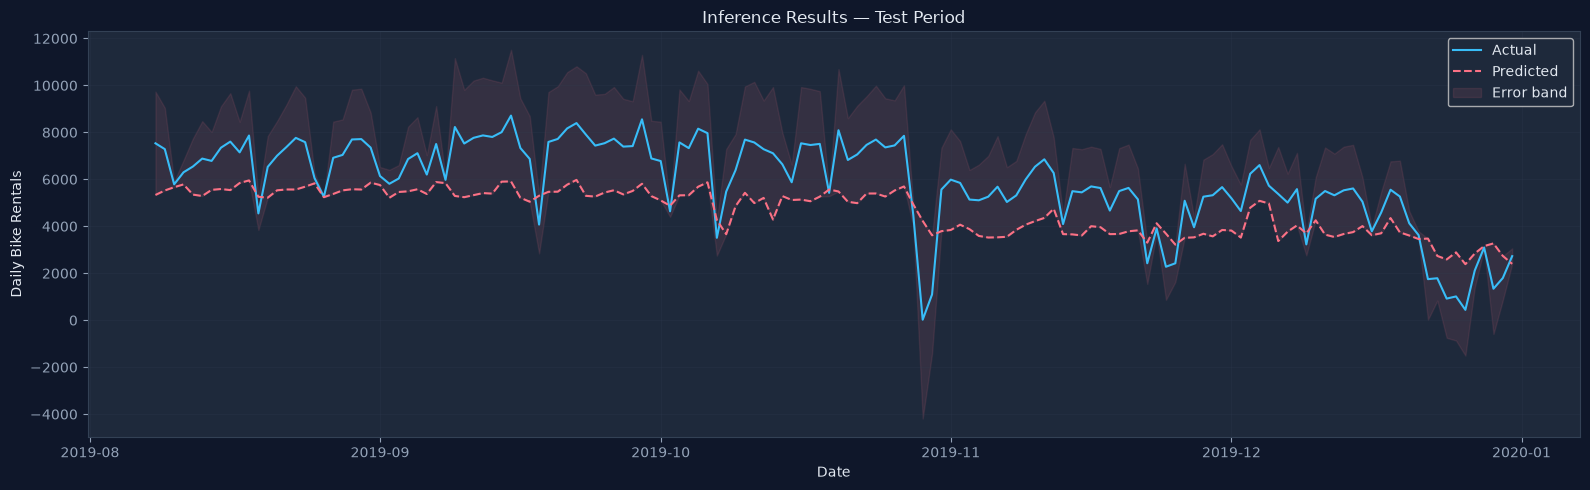

In [8]:
# ── Visualise predictions ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.facecolor':'#0f172a','axes.facecolor':'#1e293b',
    'axes.edgecolor':'#334155','axes.labelcolor':'#e2e8f0','xtick.color':'#94a3b8',
    'ytick.color':'#94a3b8','text.color':'#e2e8f0','grid.color':'#334155'})

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(result_df['date'], result_df['actual'],    color='#38bdf8', label='Actual',    linewidth=1.5)
ax.plot(result_df['date'], result_df['predicted'], color='#fb7185', label='Predicted', linewidth=1.5, linestyle='--')
ax.fill_between(result_df['date'],
    result_df['actual'] - result_df['abs_error'],
    result_df['actual'] + result_df['abs_error'],
    alpha=0.1, color='#fb7185', label='Error band')
ax.set(title='Inference Results — Test Period', xlabel='Date', ylabel='Daily Bike Rentals')
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('../outputs/inference_results.png', dpi=150, bbox_inches='tight')
plt.show()